TITLE :

An image recognition system needs to classify handwritten digits (0-9) from the MNIST dataset using Support
Vector Machines (SVM).

In [ ]:
from sklearn import datasets, svm, metrics
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

OBJECTIVE :

To develop a machine learning model using the Support Vector Machine (SVM) algorithm to classify handwritten digits (0–9) from the MNIST (Digits) dataset and to compare the performance of linear and polynomial kernels.

THEORY :

 1. Introduction to SVM

Support Vector Machine (SVM) is a supervised machine learning algorithm mainly used for classification tasks.
It works by finding the best separating hyperplane that divides data points of different classes with the maximum margin.

SVM tries to find:

                       max * 2 / ||w||
	​


subject to all data points being correctly classified and lying on the correct side of the margin.

The data points that lie closest to the hyperplane are called Support Vectors, and they are the key elements that define the decision boundary.

 2. Working of SVM

SVM maps input data into a high-dimensional feature space.

It finds an optimal hyperplane that separates the classes with maximum distance.

For non-linearly separable data, it uses kernel functions to transform the data into higher dimensions where separation becomes possible.

3. Types of Kernels

Linear Kernel:

Used when data is linearly separable.

Simple and faster to train.

Equation:

𝐾
(
𝑥
𝑖
,
𝑥
𝑗
)
=
𝑥
𝑖
⋅
𝑥
𝑗
K(x
i
	​,x
j
	​) = x
i
	​
⋅x
j
	​


Polynomial Kernel:

Used when data has a more complex, curved decision boundary.

Captures interactions between features.

Equation:

𝐾
(
𝑥
𝑖
,
𝑥
𝑗
)
=
(
𝑥
𝑖
⋅
𝑥
𝑗
+
𝑐
)
𝑑
K(x
i
	​,x
j
	​) = (x
i
	​⋅x
j
	​+c)
d

where d = degree of the polynomial.

Advantages of SVM:

Works well on both linear and nonlinear data.

High accuracy for image recognition tasks.

Robust against overfitting in high-dimensional spaces.


Applications of SVM:

Handwritten character recognition

Face detection

Spam classification

Bioinformatics and medical image analysis

In [ ]:
# Step 1: Load the dataset
digits = datasets.load_digits()
print("Dataset loaded successfully!")
print("Total samples:", len(digits.data))
print("Features per sample:", digits.data.shape[1])
print("Number of target classes:", len(set(digits.target)))

Dataset loaded successfully!
Total samples: 1797
Features per sample: 64
Number of target classes: 10


In this step, the Digits dataset from sklearn.datasets is loaded into the program.
This dataset contains 1797 grayscale images of handwritten digits (0–9), where each image is 8×8 pixels in size.
Each image is converted into a feature vector of 64 values (pixel intensities).
The dataset also includes the target labels (0–9) representing the actual digit in each image.

This step helps prepare the input data and target labels required for training and testing the SVM model.

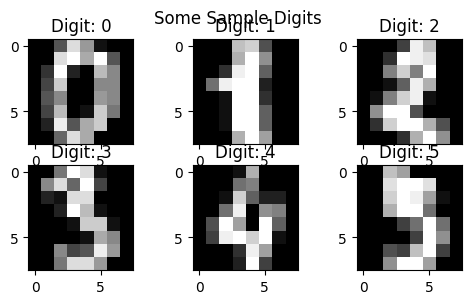

In [ ]:
# Step 2: Show few sample images
plt.figure(figsize=(6, 3))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(digits.images[i], cmap='gray')
    plt.title(f"Digit: {digits.target[i]}")
plt.suptitle("Some Sample Digits")
plt.show()

This snippet shows some sample images form dataset

In [ ]:
# Step 3: Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    digits.data, digits.target, test_size=0.3, random_state=10
)
print("\nTraining size:", len(X_train))
print("Testing size:", len(X_test))


Training size: 1257
Testing size: 540


In this step, the dataset is divided into training and testing subsets using train_test_split.

Training set (X_train, y_train): Used by the SVM model to learn patterns from the digit images.

Testing set (X_test, y_test): Used to evaluate the model’s performance on unseen data.

Here, 30% of the data is reserved for testing (test_size=0.3), and 70% for training.
The random_state ensures reproducibility, meaning the split will be the same every time the code runs.

This step is crucial to assess the generalization ability of the model and avoid overfitting.

In [ ]:
# Step 4: Train SVM with Linear Kernel
print("\nTraining SVM (Linear Kernel)...")
model_linear = svm.SVC(kernel='linear')
model_linear.fit(X_train, y_train)
print("Linear Kernel training done!")


Training SVM (Linear Kernel)...
Linear Kernel training done!


In this step, a Support Vector Machine (SVM) classifier with a linear kernel is created and trained.

Linear kernel assumes that the classes (digits) can be separated by a straight line (or hyperplane) in the feature space.

The SVM algorithm finds the optimal hyperplane that maximizes the margin between different digit classes.

The .fit() method trains the model using the training data (X_train) and labels (y_train), learning the patterns in the handwritten digit images.

In [ ]:
# Step 5: Train SVM with Polynomial Kernel
print("\nTraining SVM (Polynomial Kernel)...")
model_poly = svm.SVC(kernel='poly', degree=3)
model_poly.fit(X_train, y_train)
print("Polynomial Kernel training done!")


Training SVM (Polynomial Kernel)...
Polynomial Kernel training done!


In this step, a Support Vector Machine (SVM) classifier with a polynomial kernel is created and trained.

The polynomial kernel allows the SVM to handle non-linear relationships between features by mapping the input data into a higher-dimensional space.

degree=3 specifies that a cubic polynomial is used to capture complex patterns in the data.

The .fit() method trains the model on the training data (X_train) and labels (y_train), enabling it to learn curved decision boundaries that better separate the handwritten digit classes.

In [ ]:
# Step 6: Predictions
y_pred_linear = model_linear.predict(X_test)
y_pred_poly = model_poly.predict(X_test)

In [ ]:
# Step 7: Accuracy and Reports
print("\nResults for Linear Kernel SVM:")
print("Accuracy:", round(metrics.accuracy_score(y_test, y_pred_linear) * 100, 2), "%")
print(metrics.classification_report(y_test, y_pred_linear))


Results for Linear Kernel SVM:
Accuracy: 98.15 %
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        51
           1       0.98      0.98      0.98        57
           2       1.00      1.00      1.00        55
           3       1.00      0.98      0.99        56
           4       0.98      1.00      0.99        51
           5       0.94      1.00      0.97        51
           6       1.00      0.98      0.99        55
           7       0.98      1.00      0.99        60
           8       0.96      0.90      0.93        50
           9       0.96      0.96      0.96        54

    accuracy                           0.98       540
   macro avg       0.98      0.98      0.98       540
weighted avg       0.98      0.98      0.98       540



In [ ]:
print("\nResults for Polynomial Kernel SVM:")
print("Accuracy:", round(metrics.accuracy_score(y_test, y_pred_poly) * 100, 2), "%")
print(metrics.classification_report(y_test, y_pred_poly))


Results for Polynomial Kernel SVM:
Accuracy: 98.15 %
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        51
           1       0.98      0.98      0.98        57
           2       1.00      1.00      1.00        55
           3       0.96      0.98      0.97        56
           4       0.98      1.00      0.99        51
           5       0.98      0.98      0.98        51
           6       1.00      0.98      0.99        55
           7       0.98      0.98      0.98        60
           8       0.96      0.96      0.96        50
           9       0.96      0.96      0.96        54

    accuracy                           0.98       540
   macro avg       0.98      0.98      0.98       540
weighted avg       0.98      0.98      0.98       540



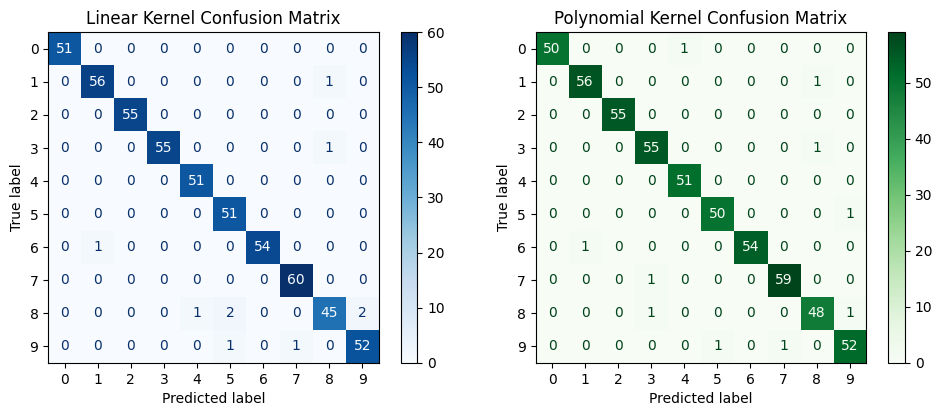

In [ ]:
# Step 8: Confusion Matrix Visualization
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
metrics.ConfusionMatrixDisplay.from_estimator(model_linear, X_test, y_test, ax=axes[0], cmap='Blues')
axes[0].set_title("Linear Kernel Confusion Matrix")

metrics.ConfusionMatrixDisplay.from_estimator(model_poly, X_test, y_test, ax=axes[1], cmap='Greens')
axes[1].set_title("Polynomial Kernel Confusion Matrix")

plt.tight_layout()
plt.show()

In [ ]:
# Step 9: Self Learning Notes
print("\n--- Self Learning Summary ---")
print("1. Linear kernel is simple and performs faster.")
print("2. Polynomial kernel tries to capture more complex patterns but may overfit.")
print("3. Both models show high accuracy on digit data.")
print("4. Visualization helps to compare model performances easily.")


--- Self Learning Summary ---
1. Linear kernel is simple and performs faster.
2. Polynomial kernel tries to capture more complex patterns but may overfit.
3. Both models show high accuracy on digit data.
4. Visualization helps to compare model performances easily.


CONCLUSION :

In this experiment, we successfully implemented a Support Vector Machine (SVM) classifier for handwritten digit recognition using the digits dataset.
Both linear and polynomial kernels achieved high accuracy, showing SVM’s efficiency in pattern recognition tasks.

The linear kernel performed slightly better and was faster to train, while the polynomial kernel captured complex data relationships but took longer.
This demonstrates how kernel choice affects both model performance and computational cost.
Overall, SVM proved to be a strong and reliable model for digit classification.